$ CH_4, SiH_4, GeH_4, SnH_4, PbH_4 $


In [13]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import Estimator

In [ ]:
# bond lengths in Angstroms (approximate tetrahedral geometries)
molecules_config = {
    'CH4': {'atom': 'C', 'bond_length': 1.087, 'basis': 'sto-3g'},
    'SiH4': {'atom': 'Si', 'bond_length': 1.48, 'basis': 'sto-3g'},
    'GeH4': {'atom': 'Ge', 'bond_length': 1.525, 'basis': 'sto-3g'},
    'SnH4': {'atom': 'Sn', 'bond_length': 1.705, 'basis': 'sto-3g'},
}

def get_tetrahedral_geometry(center_atom, dist):
    # Geometry for XH4 (Tetrahedral)
    # Center atom at origin, H atoms at tetrahedral vertices
    c = dist / np.sqrt(3)
    geometry_str = f"{center_atom} 0.0 0.0 0.0; "
    geometry_str += f"H {c} {c} {c}; "
    geometry_str += f"H {-c} {-c} {c}; "
    geometry_str += f"H {c} {-c} {-c}; "
    geometry_str += f"H {-c} {c} {-c}"
    return geometry_str

In [18]:
def solve_molecule(name, config, active_electrons=12, active_orbitals=12):
    print(f"--- Processing {name} ---")
    
    # 1. Define Driver
    geometry = get_tetrahedral_geometry(config['atom'], config['bond_length'])
    driver = PySCFDriver(
        atom=geometry,
        basis=config['basis'],
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM
    )
    problem = driver.run()
    
    # 2. Transformers (Freeze Core + Active Space)
    # First freeze core electrons to reduce problem size
    freeze_core = FreezeCoreTransformer()
    # Then select active space (Bonding orbitals usually) 
    # but (8e, 8o) is better for XH4 valence.
    as_transformer = ActiveSpaceTransformer(
        num_electrons=active_electrons, 
        num_spatial_orbitals=active_orbitals
    )
    
    # Apply transformers
    problem_reduced = freeze_core.transform(problem)
    problem_reduced = as_transformer.transform(problem_reduced)
    
    mapper = JordanWignerMapper()
    
    # 3. Exact Classical Solution (Benchmark)
    print("  Running Classical Solver...")
    start_time = time.time()
    numpy_solver = NumPyMinimumEigensolver()
    calc = GroundStateEigensolver(mapper, numpy_solver)
    res_exact = calc.solve(problem_reduced)
    exact_energy = res_exact.total_energies[0]
    time_exact = time.time() - start_time
    
    # 4. VQE Solution
    print("  Running VQE...")
    ansatz = UCCSD(
        problem_reduced.num_spatial_orbitals,
        problem_reduced.num_particles,
        mapper,
        initial_state=HartreeFock(
            problem_reduced.num_spatial_orbitals,
            problem_reduced.num_particles,
            mapper
        )
    )
    
    start_time = time.time()
    # Using Estimator (V1) as per your snippet, though V2 is recommended for newer Qiskit
    vqe = VQE(Estimator(), ansatz, SLSQP(maxiter=100))
    vqe_calc = GroundStateEigensolver(mapper, vqe)
    res_vqe = vqe_calc.solve(problem_reduced)
    vqe_energy = res_vqe.total_energies[0]
    time_vqe = time.time() - start_time
    
    # Calculate Accuracy
    error = abs(vqe_energy - exact_energy)
    
    return {
        "Molecule": name,
        "Exact Energy (Hartree)": exact_energy,
        "VQE Energy (Hartree)": vqe_energy,
        "Error (Hartree)": error,
        "Time Exact (s)": time_exact,
        "Time VQE (s)": time_vqe,
        "Qubits": problem_reduced.num_spatial_orbitals * 2
    }

In [19]:
results_data = []

# Loop through molecules
# Note: Increasing active space improves accuracy but increases simulation time drastically.
# We stick to (2,2) or (4,4) for demonstration feasibility on local hardware.
for name, config in molecules_config.items():
    try:
        # Using a minimal (2e, 2o) active space to ensure convergence speed for the larger loop
        result = solve_molecule(name, config, active_electrons=2, active_orbitals=2)
        results_data.append(result)
    except Exception as e:
        print(f"Failed to process {name}: {e}")

--- Processing CH4 ---
  Running Classical Solver...
  Running VQE...


/tmp/ipykernel_56327/2070397247.py:55: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  vqe = VQE(Estimator(), ansatz, SLSQP(maxiter=100))


--- Processing SiH4 ---
  Running Classical Solver...
  Running VQE...


/tmp/ipykernel_56327/2070397247.py:55: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  vqe = VQE(Estimator(), ansatz, SLSQP(maxiter=100))


--- Processing GeH4 ---
  Running Classical Solver...
  Running VQE...


/tmp/ipykernel_56327/2070397247.py:55: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  vqe = VQE(Estimator(), ansatz, SLSQP(maxiter=100))


--- Processing SnH4 ---
  Running Classical Solver...
  Running VQE...


/tmp/ipykernel_56327/2070397247.py:55: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  vqe = VQE(Estimator(), ansatz, SLSQP(maxiter=100))


--- Processing PbH4 ---
Failed to process PbH4: 'Failed to build the PySCF Molecule object.'



=== Comparative Results ===


,Molecule,Exact Energy (Hartree),VQE Energy (Hartree),Error (Hartree),Time Exact (s),Time VQE (s),Qubits
0,CH4,-39.727180,-39.727180,8.538095e-10,0.137895,1.306008,4
1,SiH4,-287.912378,-287.912378,2.831234e-08,0.132655,1.903738,4
2,GeH4,-2054.076829,-2054.076829,2.138299e-07,0.146738,1.562194,4
3,SnH4,-5965.611859,-5965.611858,7.152266e-08,0.147198,1.333258,4


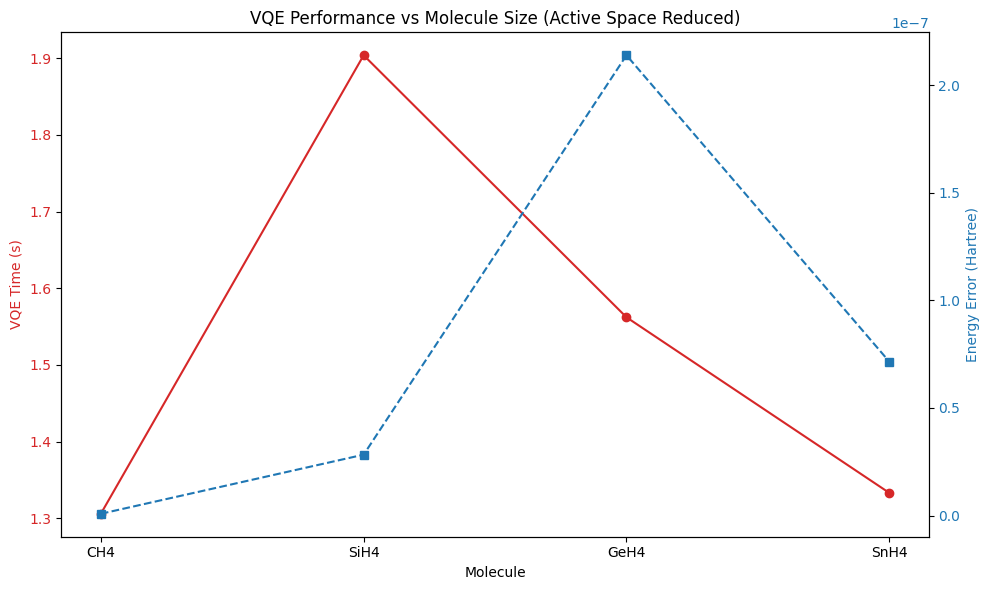

In [17]:
# Create DataFrame
df = pd.DataFrame(results_data)

# Display Table
print("\n=== Comparative Results ===")
display(df) # Use print(df) if not in Jupyter

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Time
color = 'tab:red'
ax1.set_xlabel('Molecule')
ax1.set_ylabel('VQE Time (s)', color=color)
ax1.plot(df['Molecule'], df['Time VQE (s)'], marker='o', color=color, label='VQE Time')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for Error
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Energy Error (Hartree)', color=color)
ax2.plot(df['Molecule'], df['Error (Hartree)'], marker='s', linestyle='--', color=color, label='VQE Error')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('VQE Performance vs Molecule Size (Active Space Reduced)')
fig.tight_layout()
plt.show()

In [ ]:
# from qiskit_nature.second_q.drivers import PySCFDriver
# from qiskit_nature.units import DistanceUnit


# driver = PySCFDriver(
#     atom="C 0.0000000 0.0000000 0.0000000; H 0.6305000 0.6305000 0.6305000; H -0.6305000 -0.6305000 0.6305000; H -0.6305000 0.6305000 -0.6305000; H 0.6305000 -0.6305000 -0.6305000",
#     basis="sto3g",
#     unit=DistanceUnit.ANGSTROM,
#     charge=0,
#     spin=0
# )

# full_problem = driver.run()
# print(full_problem.molecule)
# print(full_problem.num_particles)
# print(full_problem.num_spatial_orbitals)

Molecule:
	Multiplicity: 1
	Charge: 0
	Unit: Bohr
	Geometry:
		C	(0.0, 0.0, 0.0)
		H	(1.1914723215382714, 1.1914723215382714, 1.1914723215382714)
		H	(-1.1914723215382714, -1.1914723215382714, 1.1914723215382714)
		H	(-1.1914723215382714, 1.1914723215382714, -1.1914723215382714)
		H	(1.1914723215382714, -1.1914723215382714, -1.1914723215382714)
	Masses:
		C	12
		H	1
		H	1
		H	1
		H	1
(5, 5)
9


In [ ]:
# from pyscf import gto
# mol = gto.M(
#     atom="C 0.0000000 0.0000000 0.0000000; H 0.6305000 0.6305000 0.6305000; H -0.6305000 -0.6305000 0.6305000; H -0.6305000 0.6305000 -0.6305000; H 0.6305000 -0.6305000 -0.6305000",
#     basis="sto3g",)

# print(mol.tostring())

# from pyscf import tools

# def view_molecule(mol):
#     xyz_str = f"{len(mol._atom)}\n\n" + mol.tostring()
#     view = tools.visualize.view(width=400,height=400)
#     view.addModel(xyz_str, 'xyz')
#     view.setStyle({'stick':{},'sphere':{'scale':0.3}})
#     view.zoomTo()
#     return view.show()

# view_molecule(mol)

C           0.00000        0.00000        0.00000
H           0.63050        0.63050        0.63050
H          -0.63050       -0.63050        0.63050
H          -0.63050        0.63050       -0.63050
H           0.63050       -0.63050       -0.63050


AttributeError: module 'pyscf.tools' has no attribute 'visualize'

In [ ]:
# from qiskit_nature.second_q.transformers import FreezeCoreTransformer

# fc_transformer = FreezeCoreTransformer(remove_orbitals=[4,5])

# fc_problem = fc_transformer.transform(full_problem)
# print(fc_problem.num_particles)
# print(fc_problem.num_spatial_orbitals)
# print(fc_problem.hamiltonian.constants)

(1, 1)
5
{'nuclear_repulsion_energy': 1.05835442184, 'FreezeCoreTransformer': -7.84030604879426}


In [ ]:
# from qiskit_nature.second_q.transformers import ActiveSpaceTransformer

# as_transformer = ActiveSpaceTransformer(2, 2)

# as_problem = as_transformer.transform(full_problem)
# print(as_problem.num_particles)
# print(as_problem.num_spatial_orbitals)


(1, 1)
2


In [ ]:
# from qiskit_nature.second_q.mappers import JordanWignerMapper
# mapper = JordanWignerMapper()


In [ ]:
# from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
# ansatz = UCCSD(
#     as_problem.num_spatial_orbitals,
#     as_problem.num_particles,
#     mapper,
#     initial_state=HartreeFock(
#         as_problem.num_spatial_orbitals,
#         as_problem.num_particles,
#         mapper,
#     ),
# )

In [ ]:
# import numpy as np
# from qiskit_algorithms import VQE
# from qiskit_algorithms.optimizers import SLSQP
# from qiskit.primitives import Estimator
# vqe = VQE(Estimator(), ansatz, SLSQP())
# vqe.initial_point = np.zeros(ansatz.num_parameters)

/tmp/ipykernel_1519/1451404600.py:5: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  vqe = VQE(Estimator(), ansatz, SLSQP())


In [ ]:
# from qiskit_nature.second_q.algorithms import GroundStateEigensolver
# solver = GroundStateEigensolver(mapper, vqe)

In [ ]:
# active_space_result = solver.solve(as_problem)
# print(active_space_result)
# print(f"Total ground state energy (Hartree) = {active_space_result.total_energies[0]:.4f}")

=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -8.921934232375
  - computed part:      -1.081628183581
  - ActiveSpaceTransformer extracted energy part: -7.840306048794
~ Nuclear repulsion energy (Hartree): 1.05835442184
> Total ground state energy (Hartree): -7.863579810535
 
=== MEASURED OBSERVABLES ===
 
  0:  # Particles: 2.000 S: 0.000 S^2: 0.000 M: 0.000
 
=== DIPOLE MOMENTS ===
 
~ Nuclear dipole moment (a.u.): [0.0  0.0  2.83458919]
 
  0: 
  * Electronic dipole moment (a.u.): [0.0  0.0  4.726256926451]
    - computed part:      [0.0  0.0  4.730048775022]
    - ActiveSpaceTransformer extracted energy part: [0.0  0.0  -0.003791848571]
  > Dipole moment (a.u.): [0.0  0.0  -1.891667736451]  Total: 1.891667736451
                 (debye): [0.0  0.0  -4.808139339532]  Total: 4.808139339532
 
Total ground state energy (Hartree) = -7.8636


In [ ]:
# from qiskit_algorithms import NumPyMinimumEigensolver
# from qiskit_nature.second_q.algorithms import GroundStateEigensolver


# classical_solver = GroundStateEigensolver(
#     JordanWignerMapper(),
#     NumPyMinimumEigensolver(),  # Exactly diagonalizes the Hamiltonian
# )

In [ ]:
# classical_result = classical_solver.solve(full_problem)
# print(classical_result)
# print(f"Total ground state energy (Hartree) = {classical_result.total_energies[0]:.4f}")

=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -8.940716708639
  - computed part:      -8.940716708639
~ Nuclear repulsion energy (Hartree): 1.05835442184
> Total ground state energy (Hartree): -7.882362286799
 
=== MEASURED OBSERVABLES ===
 
  0:  # Particles: 4.000 S: 0.000 S^2: 0.000 M: 0.000
 
=== DIPOLE MOMENTS ===
 
~ Nuclear dipole moment (a.u.): [0.0  0.0  2.83458919]
 
  0: 
  * Electronic dipole moment (a.u.): [0.0  0.0  4.65747064783]
    - computed part:      [0.0  0.0  4.65747064783]
  > Dipole moment (a.u.): [0.0  0.0  -1.82288145783]  Total: 1.82288145783
                 (debye): [0.0  0.0  -4.6333020751]  Total: 4.6333020751
 
Total ground state energy (Hartree) = -7.8824
